<a href="https://colab.research.google.com/github/Rajk21/fashion-stylist-ai/blob/research/skin_tone_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Gemini_Generated_Image_yfgf2uyfgf2uyfg.jpeg to Gemini_Generated_Image_yfgf2uyfgf2uyfg (1).jpeg


(np.float64(104.13513513513513),
 np.float64(134.6994124559342),
 np.float64(141.84817861339602))

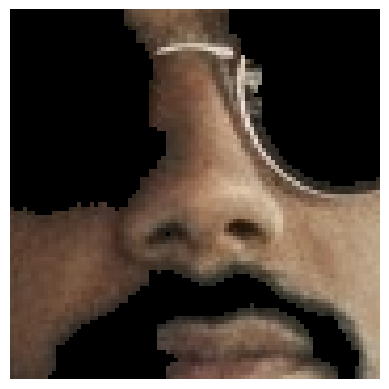

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

img = cv2.imread(list(uploaded.keys())[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(100, 100)
)

debug = img.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(debug, (x, y), (x+w, y+h), (0,255,0), 2)

plt.imshow(debug)
plt.axis("off")

x, y, w, h = faces[0]

# Crop central face area
skin_region = img[
    y + int(0.25*h) : y + int(0.75*h),
    x + int(0.25*w) : x + int(0.75*w)
]

plt.imshow(skin_region)
plt.axis("off")


lab = cv2.cvtColor(skin_region, cv2.COLOR_RGB2LAB)

hsv = cv2.cvtColor(skin_region, cv2.COLOR_RGB2HSV)

lower_skin = np.array([0, 20, 70], dtype=np.uint8)
upper_skin = np.array([20, 255, 255], dtype=np.uint8)

mask = cv2.inRange(hsv, lower_skin, upper_skin)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask = cv2.erode(mask, kernel, iterations=1)
mask = cv2.dilate(mask, kernel, iterations=2)

skin_only = cv2.bitwise_and(skin_region, skin_region, mask=mask)

plt.imshow(skin_only)
plt.axis("off")

lab = cv2.cvtColor(skin_only, cv2.COLOR_RGB2LAB)

L, A, B = cv2.split(lab)

skin_pixels = mask > 0

avg_L = np.mean(L[skin_pixels])
avg_A = np.mean(A[skin_pixels])
avg_B = np.mean(B[skin_pixels])

avg_L, avg_A, avg_B


